In [7]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

In [3]:
df = pd.read_csv("data/linkers.csv", encoding = 'latin1')

In [4]:
df.head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,K-means,scaffold_smiles,source
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,CC(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](CCCCNC...,3.508295,204.30,0.036588,4.5636,689.72,12,O=C(CCc1ccccc1)NCC(=O)Nc1ccc(COC(=O)Oc2ccccc2)cc1,train
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,C1CC(=O)N(C1=O)OC(=O)CCCCCN2C(=O)C=CC2=O,2.676214,101.06,0.487410,0.0790,308.29,4,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,train
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,3.338596,171.88,0.163403,3.6140,601.70,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,3.753739,230.32,0.030495,5.7455,766.81,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,3.796268,258.47,0.032958,2.8084,737.77,12,O=C(CCCCCN1C(=O)C=CC1=O)NCC(=O)NCC(=O)Nc1ccc(C...,train


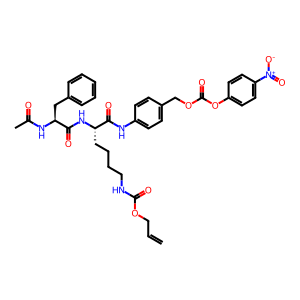

In [9]:
mol = Chem.MolFromSmiles("CC(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](CCCCNC(=O)OCC=C)C(=O)NC2=CC=C(C=C2)COC(=O)OC3=CC=C(C=C3)[N+](=O)[O-]")
Draw.MolToImage(mol)

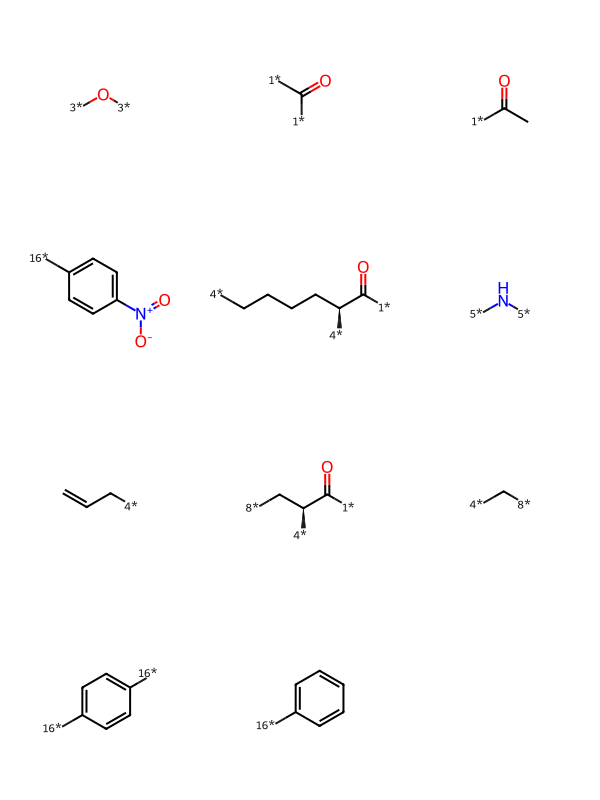

In [10]:
frags = BRICS.BRICSDecompose(mol)
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in frags])

In [11]:
frags

{'[1*]C(=O)[C@@H]([4*])CCCC[4*]',
 '[1*]C(=O)[C@@H]([4*])C[8*]',
 '[1*]C(C)=O',
 '[1*]C([1*])=O',
 '[16*]c1ccc([16*])cc1',
 '[16*]c1ccc([N+](=O)[O-])cc1',
 '[16*]c1ccccc1',
 '[3*]O[3*]',
 '[4*]CC=C',
 '[4*]C[8*]',
 '[5*]N[5*]'}

In [20]:
all_fragments = []

skipped_count = 0
for i, smile in enumerate(df['smiles']):
    print(f"{i+1}/{len(df)}, skipped = {skipped_count}", end='\r')
    mol = Chem.MolFromSmiles(smile)

    if mol is None:
        skipped_count += 1
        continue
    
    if mol.GetNumAtoms() > 500:
        skipped_count += 1
        continue

    frags = BRICS.BreakBRICSBonds(mol)
    frag_smiles = Chem.MolToSmiles(frags).split('.')
    all_fragments.extend(frag_smiles)

In [27]:
frags_series = pd.Series(all_fragments)
frags_df = pd.DataFrame(frags_series.value_counts().reset_index())
frags_df = frags_df.rename(columns={'index': 'frags'})
frags_df

,frags,count
0,[3*]O[3*],31673
1,[4*]CC[4*],29166
2,[5*]N[5*],1975
3,[1*]C(=O)CC[4*],1420
4,[4*]C(C)(C)C,985
...,...,...
276,[1*]C(=O)CCC([4*])C([1*])=O,1
277,[1*]C(=O)CCCCC(=O)O,1
278,[1*]C(=O)C(C)(C)Br,1
279,[1*]C(=O)CCCCCCCCCCCCCCCCC(=O)O,1


In [29]:
def label_frags(smile):
    stars = smile.count('*')
    if stars == 1: return "Terminal (Head/Tail)"
    if stars == 2: return "Linker (Spacer/Cleavable)"
    return "Branching/Complex"

frags_df['Category'] = frags_df['frags'].apply(label_frags)

In [31]:
frags_df

,frags,count,Category
0,[3*]O[3*],31673,Linker (Spacer/Cleavable)
1,[4*]CC[4*],29166,Linker (Spacer/Cleavable)
2,[5*]N[5*],1975,Linker (Spacer/Cleavable)
3,[1*]C(=O)CC[4*],1420,Linker (Spacer/Cleavable)
4,[4*]C(C)(C)C,985,Terminal (Head/Tail)
...,...,...,...
276,[1*]C(=O)CCC([4*])C([1*])=O,1,Branching/Complex
277,[1*]C(=O)CCCCC(=O)O,1,Terminal (Head/Tail)
278,[1*]C(=O)C(C)(C)Br,1,Terminal (Head/Tail)
279,[1*]C(=O)CCCCCCCCCCCCCCCCC(=O)O,1,Terminal (Head/Tail)


In [33]:
print("Top Spacers/Linkers:")
print(frags_df[frags_df['Category'].str.contains("Linker")].head(20))

print("\nTop Heads/Tails:")
print(frags_df[frags_df['Category'].str.contains("Terminal")].head(20))

Top Spacers/Linkers:
                         frags  count                   Category
0                    [3*]O[3*]  31673  Linker (Spacer/Cleavable)
1                   [4*]CC[4*]  29166  Linker (Spacer/Cleavable)
2                    [5*]N[5*]   1975  Linker (Spacer/Cleavable)
3              [1*]C(=O)CC[4*]   1420  Linker (Spacer/Cleavable)
6                [1*]C([1*])=O    695  Linker (Spacer/Cleavable)
15           [1*]C(=O)CCCC[8*]    239  Linker (Spacer/Cleavable)
16                   [4*]C[8*]    231  Linker (Spacer/Cleavable)
20             [1*]C(=O)CC[8*]    190  Linker (Spacer/Cleavable)
21             [1*]C(=O)NO[3*]    164  Linker (Spacer/Cleavable)
22        [16*]c1ccc([16*])cc1    161  Linker (Spacer/Cleavable)
26                [11*]SS[11*]    150  Linker (Spacer/Cleavable)
28              [1*]C(=O)C[4*]    132  Linker (Spacer/Cleavable)
29        [1*]C(=O)CCC([1*])=O    129  Linker (Spacer/Cleavable)
32                  [4*]CC[8*]    109  Linker (Spacer/Cleavable)
33  

In [128]:
head_smarts = [
    "[10*]N1C(=O)C=CC1=O",       # Maleimide
    "[3*]ON1C(=O)CCC1=O",        # NHS
    "[4*]CCN=[N+]=[N-]",         # Azide
    "[4*]CC#C",                  # Alkyne
    "[5*]N1Cc2ccccc2C#Cc2ccccc21", # DBCO
    "[4*]CCBr"                   # Bromo
]


tail_smarts = [
    "[4*]CCC(=O)O",             # acid
    "[4*]CC(=O)O",              # acid
    "[4*]C(C)(C)C",             # t-butyl
    "[4*]CCN",                  # amine
    "[5*]NC",                   # amine
    "[16*]c1ccccc1",            # PABC
    "[4*]CCO",                  # ether
    "[4*]CC"                    # ethyl
]

In [129]:
spacer_unit_smarts = [
    "[3*]O[3*]",                # Oxygen (Ether) - Crucial for PEGs
    "[4*]CC[4*]",               # Ethyl - Crucial for Alkyls/PEGs
    "[5*]N[5*]",                # Nitrogen - Secondary amines
    "[1*]C(=O)CC[4*]",          # Propionyl extender
    "[1*]C([1*])=O",            # Carbonyl
    "[1*]C(=O)CCCC[8*]",        # Valeryl extender
    "[4*]C[8*]",                # Methyl bridge
    "[1*]C(=O)CC[8*]",          # Propionyl variant
    "[1*]C(=O)NO[3*]",          # Alkoxyamine (Connector)
    "[1*]C(=O)C[4*]",           # Acetyl
    "[1*]C(=O)CCC([1*])=O",     # Glutaric (Crosslinker)
    "[4*]CC[8*]",               # Ethyl variant
    "[1*]C([6*])=O",            # Carbonyl variant
    "[1*]C(=O)CCC[4*]",         # Butyryl
    "[4*]CCC[4*]",              # Propyl
    "[4*]C([8*])C",             # Iso-propyl
]

cleavable_smarts = [
    "[16*]c1ccc([16*])cc1",         # PABC Core (Self-immolative ring)
    "[11*]SS[11*]",                 # Disulfide Bond (Reducible)
    "[1*]C(=O)[C@@H]([4*])C(C)C",   # Valine (Part of Val-Cit peptide)
    "[1*]C(=O)NNC(=O)CC[4*]",       # Hydrazone (pH Sensitive)
]

In [204]:
import random

def get_weighted_frags(df, smarts_list):
    subset = df[df['frags'].isin(smarts_list)]
    population = subset['frags'].tolist()
    weights = subset['count'].tolist()
    return population, weights

head_pop, head_w = get_weighted_frags(frags_df, head_smarts)
tail_pop, tail_w = get_weighted_frags(frags_df, tail_smarts)
cleave_pop, cleave_w = get_weighted_frags(frags_df, cleavable_smarts)
spacer_pop, spacer_w = get_weighted_frags(frags_df, spacer_unit_smarts)

In [205]:
# Convert to set for fast lookup
head_set = set(head_pop)

# Filter the tails
clean_tail_pop = []
clean_tail_w = []

for smi, w in zip(tail_pop, tail_w):
    if smi not in head_set:
        clean_tail_pop.append(smi)
        clean_tail_w.append(w)
    else:
        print(f"Removed Head from Tail list: {smi}")

# Update the variables
tail_pop = clean_tail_pop
tail_w = clean_tail_w

In [208]:
def build_linker(num_spacers=5):
    num_spacers = num_spacers + random.randint(0, num_spacers)
    head = random.choices(head_pop, k=1)[0]
    tail = random.choices(tail_pop, k=1)[0]
    cleavable = random.choices(cleave_pop, k=1)[0]
    spacers = random.choices(spacer_pop, k=num_spacers)

    combined = [head, tail, cleavable] + spacers
    frag_mol = [Chem.MolFromSmiles(x) for x in combined]

    builder = BRICS.BRICSBuild(frag_mol)

    try:
        for _ in range(20): # give 20 attempts at building a valid linker
            mol = next(builder)
            smi = Chem.MolToSmiles(mol)

            # needs to be reasonably long and can't have unreacted frags (*)
            if mol.GetNumAtoms() > 10 and "*" not in smi:
                return smi 

    except StopIteration:
        pass

    return None

In [209]:
smiles = build_linker()

In [210]:
smiles

'O=C1C=CC(=O)N1C(=O)N1C(=O)C=CC1=O'

In [211]:
pbar.close()

 36%|███▌      | 3616/10000 [42:47<1:15:33,  1.41it/s]


In [212]:
from tqdm import tqdm # Progress bar

target_molecules = 10_000
existing_mols = set(df['smiles'].unique())
synthetic_smiles = set()

pbar = tqdm(total=target_molecules)

while len(synthetic_smiles) < target_molecules:
    raw_smile = build_linker()

    if raw_smile:
        mol = Chem.MolFromSmiles(raw_smile)
        if mol:
            canon_smi = Chem.MolToSmiles(mol, canonical=True)

            if (canon_smi not in synthetic_smiles) and (canon_smi not in existing_mols):
                synthetic_smiles.add(canon_smi)
                pbar.update(1)

pbar.close()

 98%|█████████▊| 9810/10000 [5:53:45<3:12:16, 60.72s/it]

KeyboardInterrupt: 

In [ ]:
new_df = pd.DataFrame()
new_df['smiles'] = existing_mols + synthetic_smiles